importing all req librares

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

selecting all three columns

In [25]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


applying K-Mean

In [26]:
features = df[["Age","Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
features = scaler.fit_transform(features)

printing all clusters centres

print(df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]].head(20))

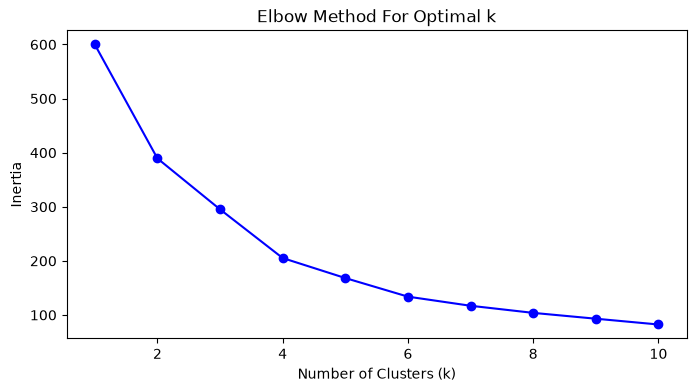

In [27]:
inertia = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(features)
  inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", linestyle="-", color="b")
plt.title("Elbow Method For Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [28]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(features)

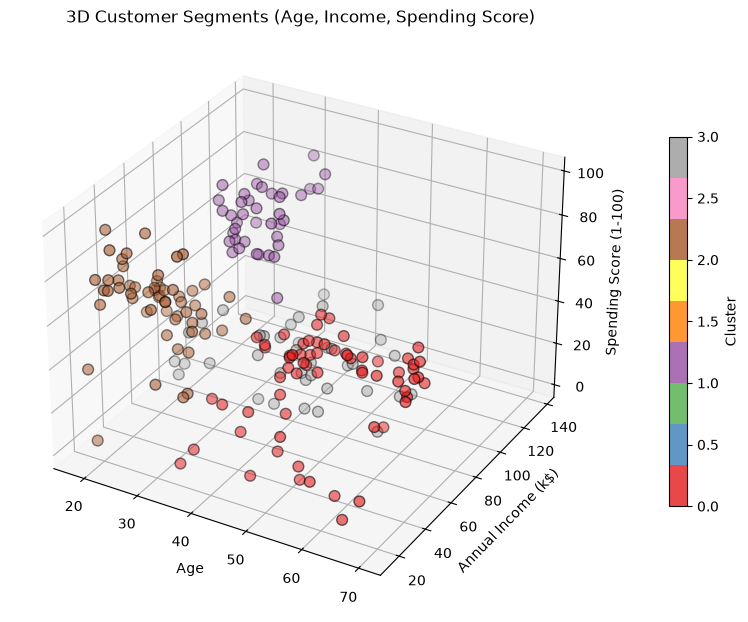

In [29]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(
    111, projection="3d"
)  # Creates a 3D projection axes

# Scatter plot using 3 axes: Age (X), Annual Income (Y), Spending Score (Z)
scatter = ax.scatter(
    xs=df["Age"],
    ys=df["Annual Income (k$)"],
    zs=df["Spending Score (1-100)"],
    c=df["Cluster"],  # Colors points based on cluster assignments
    cmap="Set1",  # Colormap corresponding to your clusters
    s=60,  # Size of the markers
    alpha=0.8,
    edgecolor="k",
)

# Set labels for each axis
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.set_title("3D Customer Segments (Age, Income, Spending Score)")

# Add a color bar legend for the clusters
plt.colorbar(
    scatter, label="Cluster", ax=ax, pad=0.1, shrink=0.6
)  # Note: Adjust pad/shrink to fit layout

plt.show()

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c="yellow",
    marker="X",
    edgecolor="black",
    label="Centroids",
)

plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()